In [3]:
import requests
import time
import random
import sqlite3
import re

# --- СПИСОК МАРОК ---
TARGET_BRANDS = [
    'skoda', 'volkswagen', 'bmw', 'audi', 'mercedes-benz', 
    'ford', 'hyundai', 'kia', 'toyota', 'renault', 
    'peugeot', 'seat', 'opel', 'citroen', 'fiat', 
    'mazda', 'honda', 'nissan', 'volvo', 'subaru'
]

DB_NAME = "cars.db"

# --- 1. ФУНКЦИЯ ДЛЯ ВЫТАСКИВАНИЯ МОЩНОСТИ ---
def parse_power(text):
    if not text: return None
    # Ищем "85 kW", "110kw", "150 KW"
    match = re.search(r'(\d+)\s*[kK][wW]', str(text))
    if match:
        return int(match.group(1))
    return None

# --- 2. НАСТРОЙКА БАЗЫ ДАННЫХ ---
def init_db():
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    # Добавили колонку details (туда положим additional_model_name)
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS cars (
            id INTEGER PRIMARY KEY,
            brand TEXT,
            model_name TEXT,
            details TEXT,  
            price INTEGER,
            year INTEGER,
            mileage INTEGER,
            fuel TEXT,
            gearbox TEXT,
            power INTEGER,
            url TEXT,
            parsed_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    ''')
    conn.commit()
    return conn

# Подключаемся
conn = init_db()
cursor = conn.cursor()

url = "https://www.sauto.cz/api/v1/items/search"
headers = {
    'accept': 'application/json',
    'content-type': 'application/json',
    'user-agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
}

print(f"🚀 ЗАПУСК V2: Сбор данных с расширенными параметрами...")

total_saved = 0

for brand in TARGET_BRANDS:
    print(f"\n🚘 --- Марка: {brand.upper()} ---")
    page = 0
    max_pages = 50 
    
    while page < max_pages:
        params = {
            'limit': 20,
            'offset': page * 20,
            'category_id': 838,
            'condition_seo': 'nove,ojete,predvadeci',
            'manufacturer_model_seo': brand,
        }
        
        print(f"   ⏳ {brand}: стр. {page + 1} | В базе: {total_saved}...", end="\r", flush=True)
        
        try:
            response = requests.get(url, headers=headers, params=params, timeout=5)
            
            if response.status_code == 200:
                data = response.json()
                results = data.get("results", [])
                
                if not results:
                    break
                
                for car in results:
                    car_id = car.get("id")
                    name = car.get("name")
                    
                    # --- НОВОЕ ПОЛЕ ---
                    # Берем детальное описание ("Selection 1.5 TSI...")
                    details = car.get("additional_model_name") 
                    
                    price = car.get("price")
                    
                    date_str = car.get("manufacturing_date") or car.get("in_operation_date") or ""
                    year = int(date_str[:4]) if date_str and date_str[:4].isdigit() else None
                    
                    mileage = car.get("tachometer")
                    fuel = car.get("fuel_cb", {}).get("name")
                    gearbox = car.get("gearbox_cb", {}).get("name")
                    
                    # --- УЛУЧШЕННЫЙ ПОИСК МОЩНОСТИ ---
                    # 1. Сначала пробуем взять готовое поле power
                    power = car.get("power")
                    # 2. Если пусто, ищем в детальном описании (там надежнее всего)
                    if not power:
                        power = parse_power(details)
                    # 3. Если и там нет, ищем в обычном имени
                    if not power:
                        power = parse_power(name)
                    
                    seo_url = car.get("seo", {}).get("url")
                    full_url = seo_url if seo_url else f"https://www.sauto.cz/osobni/detail/{brand}/car/{car_id}"

                    # Сохраняем новую структуру
                    cursor.execute('''
                        INSERT OR IGNORE INTO cars 
                        (id, brand, model_name, details, price, year, mileage, fuel, gearbox, power, url)
                        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                    ''', (car_id, brand, name, details, price, year, mileage, fuel, gearbox, power, full_url))
                
                conn.commit()
                total_saved += len(results)
                page += 1
                
            else:
                break
                
        except Exception:
            break
            
        time.sleep(random.uniform(0.3, 0.6))

conn.close()
print(f"\n\n🏁 ГОТОВО! Обновленная база собрана.")

🚀 ЗАПУСК V2: Сбор данных с расширенными параметрами...

🚘 --- Марка: SKODA ---
   ⏳ skoda: стр. 50 | В базе: 980...
🚘 --- Марка: VOLKSWAGEN ---


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import sqlite3
import numpy as np

# 1. Подключение
conn = sqlite3.connect("cars.db")
df = pd.read_sql("SELECT * FROM cars", conn)
conn.close()

print(f"📥 Сырых данных: {len(df)}")

# --- ФИЛЬТРАЦИЯ ---
# Убираем выбросы по цене (хлам до 30к и эксклюзив выше 5млн)
df = df[(df['price'] > 30000) & (df['price'] < 5000000)]

# Убираем дубликаты (если вдруг ID повторились)
df = df.drop_duplicates(subset=['id'])

# --- УДАЛЕНИЕ ЛИШНЕГО ---
# id, url, parsed_at - не влияют на физику цены
# model_name - убираем, так как у нас есть более точный 'details'
cols_to_drop = ['id', 'url', 'parsed_at', 'model_name']
df = df.drop(columns=cols_to_drop, errors='ignore')

# --- ОБРАБОТКА ПРОПУСКОВ (Imputation) ---
# Для текста: заменяем NaN на "Unknown"
text_cols = ['brand', 'details', 'fuel', 'gearbox']
for col in text_cols:
    df[col] = df[col].fillna("Unknown")

# Для чисел: если мощность не найдена, ставим -1 (CatBoost поймет, что это пропуск)
# Либо можно поставить медиану: df['power'].median()
df['power'] = pd.to_numeric(df['power'], errors='coerce').fillna(-1)

# --- СОХРАНЕНИЕ ---
# Сохраняем в CSV, чтобы визуализация и ML читали уже чистый файл
output_file = "cars_ready.csv"
df.to_csv(output_file, index=False)

print(f"🧹 После очистки: {len(df)}")
print(f"💾 Данные сохранены в '{output_file}'")
print(df.head(3))

📥 Сырых данных: 19022
🧹 После очистки: 18825
💾 Данные сохранены в 'cars_ready.csv'
     brand                        details  price  year  mileage   fuel  \
0  renault      Serviska cebia VIN MAILEM  79000  2010   223000  Nafta   
1   subaru  2,0 Active Combi, nová spojka  77000  2009   189704  Nafta   
2   nissan            1.9 dCi First Class  40000  2003   207000  Nafta   

       gearbox  power  
0  Automatická   -1.0  
1     Manuální   -1.0  
2     Manuální   -1.0  


📂 Данные загружены: 18825 строк


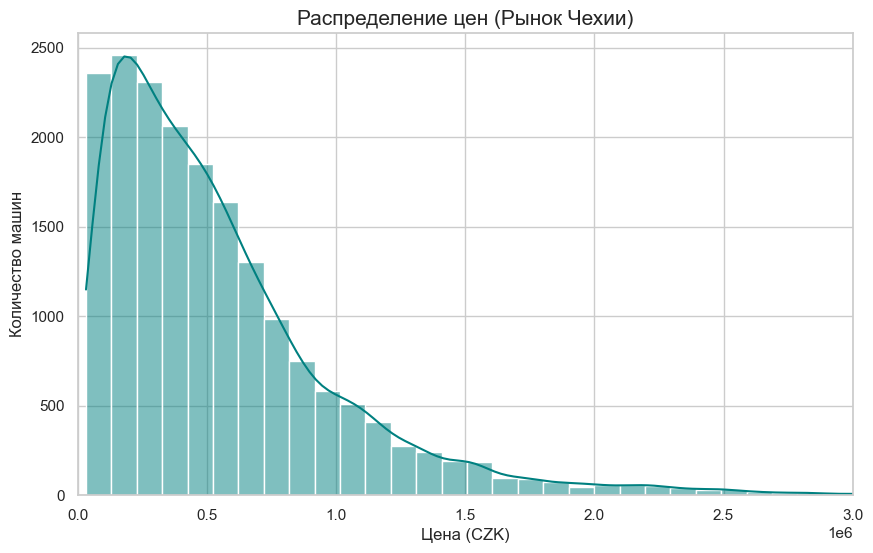

/var/folders/nf/_plpz1p57pv31n9md8s7b1s40000gn/T/ipykernel_71076/3676913735.py:42: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




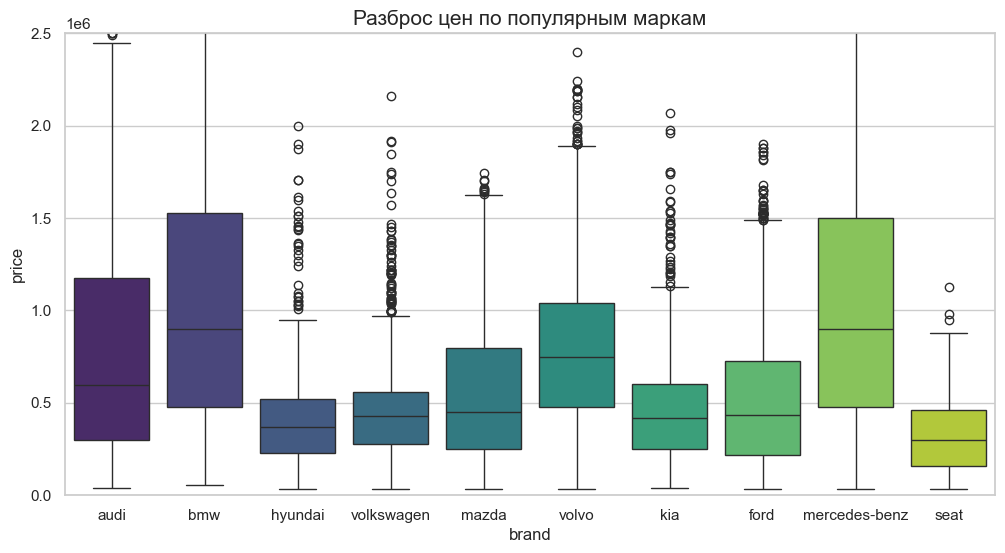

/var/folders/nf/_plpz1p57pv31n9md8s7b1s40000gn/T/ipykernel_71076/3676913735.py:51: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




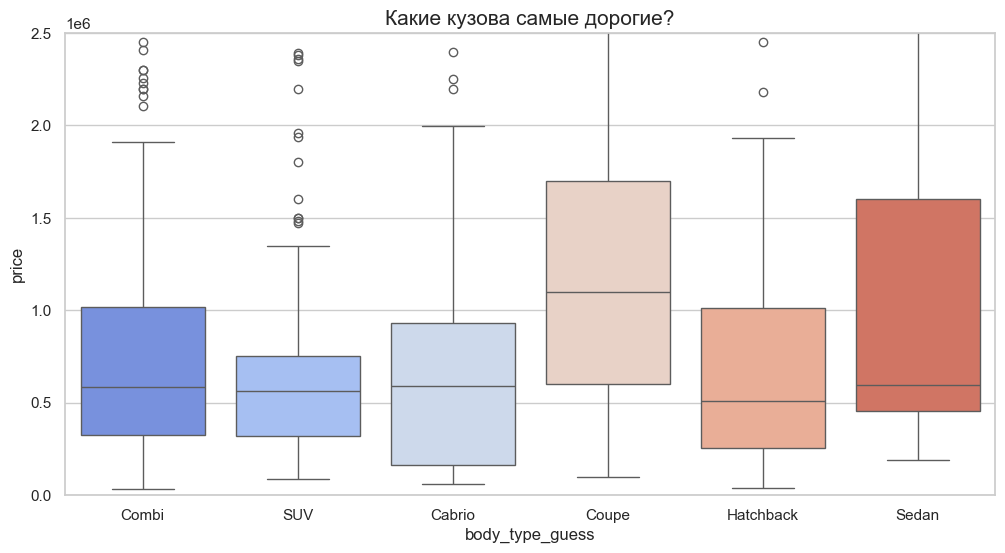

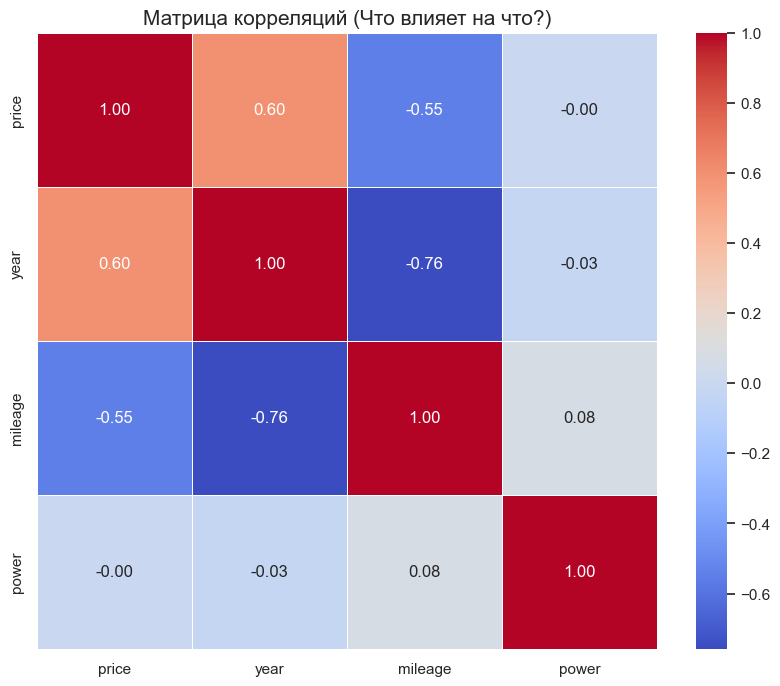

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Загружаем данные
df = pd.read_csv("cars_ready.csv")
print(f"📂 Данные загружены: {len(df)} строк")

# --- ХАК: Достаем Тип Кузова из текста для графика ---
def guess_body_type(text):
    t = str(text).lower()
    if any(x in t for x in ['combi', 'kombi', 'avant', 'variant', 'touring', 'sw']): return 'Combi'
    if any(x in t for x in ['suv', 'cross', 'tiguan', 'kodiaq', 'touareg', 'x5', 'q7', 'cr-v']): return 'SUV'
    if any(x in t for x in ['sedan', 'limuzina', 'limousin']): return 'Sedan'
    if any(x in t for x in ['hatchback', 'fabia', 'golf', 'polo']): return 'Hatchback'
    if any(x in t for x in ['coupe', 'coupé']): return 'Coupe'
    if any(x in t for x in ['cabrio', 'kabrio']): return 'Cabrio'
    return 'Other'

df['body_type_guess'] = df['details'].apply(guess_body_type)

# --- ГРАФИК 1: Гистограмма (Как распределены цены?) ---
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True, color='teal')
plt.title('Распределение цен (Рынок Чехии)', fontsize=15)
plt.xlabel('Цена (CZK)')
plt.ylabel('Количество машин')
plt.xlim(0, 3000000) # Обрезаем хвост > 3 млн для красоты
plt.show()

# --- ГРАФИК 2: Boxplot (Цена vs Марка) ---
# Берем только Топ-10 марок, иначе будет каша
top_brands = df['brand'].value_counts().head(10).index
df_top = df[df['brand'].isin(top_brands)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='brand', y='price', data=df_top, palette='viridis', order=top_brands)
plt.title('Разброс цен по популярным маркам', fontsize=15)
plt.ylim(0, 2500000)
plt.show()

# --- ГРАФИК 3: Boxplot (Цена vs Тип Кузова) ---
plt.figure(figsize=(12, 6))
# Уберем категорию "Other", чтобы не мешала
df_body = df[df['body_type_guess'] != 'Other']
sns.boxplot(x='body_type_guess', y='price', data=df_body, palette='coolwarm')
plt.title('Какие кузова самые дорогие?', fontsize=15)
plt.ylim(0, 2500000)
plt.show()

# --- ГРАФИК 4: Heatmap (Что с чем связано?) ---
# Считаем корреляцию только для чисел
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Матрица корреляций (Что влияет на что?)', fontsize=15)
plt.show()

--- 📊 Статистика по колонке power ---


count    18825.000000
mean        32.566215
std         75.761477
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         70.000000
max       5184.000000
Name: power, dtype: float64


--- 🏎️ Топ-5 авто с МАКСИМАЛЬНОЙ мощностью (ищем выбросы сверху) ---


,price,year,mileage,power
11917,559900,2019,137865,5184.0
8957,270000,2017,173955,4129.0
2710,1659900,2025,0,478.0
2602,3999000,2026,12,471.0
1129,3499000,2024,23005,463.0



--- 🐢 Топ-5 авто с МИНИМАЛЬНОЙ мощностью (ищем нули или мусор снизу) ---


,price,year,mileage,power
0,79000,2010,223000,-1.0
17702,120000,2011,221229,-1.0
10943,799000,2022,36388,-1.0
10944,369900,2023,56500,-1.0
10945,1559690,2026,1,-1.0


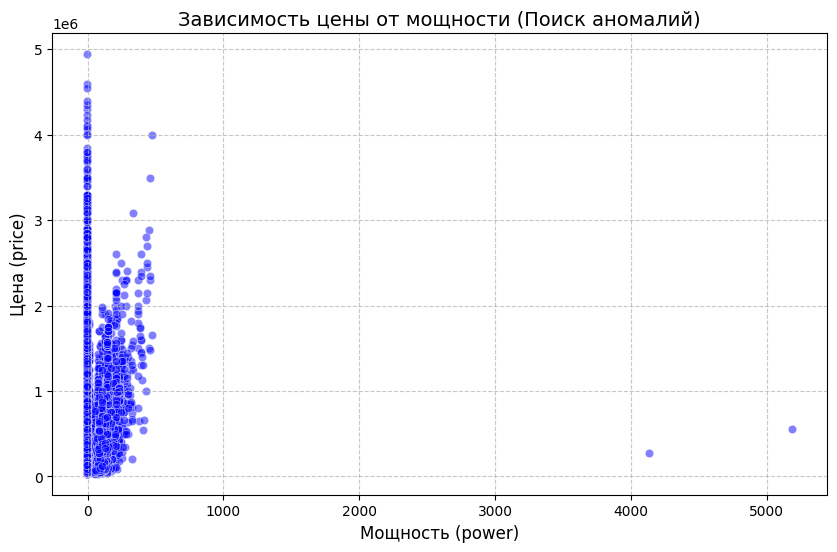

In [2]:
import pandas as pd

# Загружаем датасет (если очищенные данные в другом файле, поменяй название)
df = pd.read_csv('cars_ready.csv')

import matplotlib.pyplot as plt
import seaborn as sns

# Если твой датафрейм называется не df, просто поменяй df на свое название! 😉

print("--- 📊 Статистика по колонке power ---")
display(df['power'].describe())

print("\n--- 🏎️ Топ-5 авто с МАКСИМАЛЬНОЙ мощностью (ищем выбросы сверху) ---")
display(df[['price', 'year', 'mileage', 'power']].sort_values(by='power', ascending=False).head(5))

print("\n--- 🐢 Топ-5 авто с МИНИМАЛЬНОЙ мощностью (ищем нули или мусор снизу) ---")
display(df[['price', 'year', 'mileage', 'power']].sort_values(by='power').head(5))

# Строим точечный график
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='power', y='price', alpha=0.5, color='blue')
plt.title('Зависимость цены от мощности (Поиск аномалий)', fontsize=14)
plt.xlabel('Мощность (power)', fontsize=12)
plt.ylabel('Цена (price)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

🔥 Новая корреляция между ценой и мощностью: 0.50


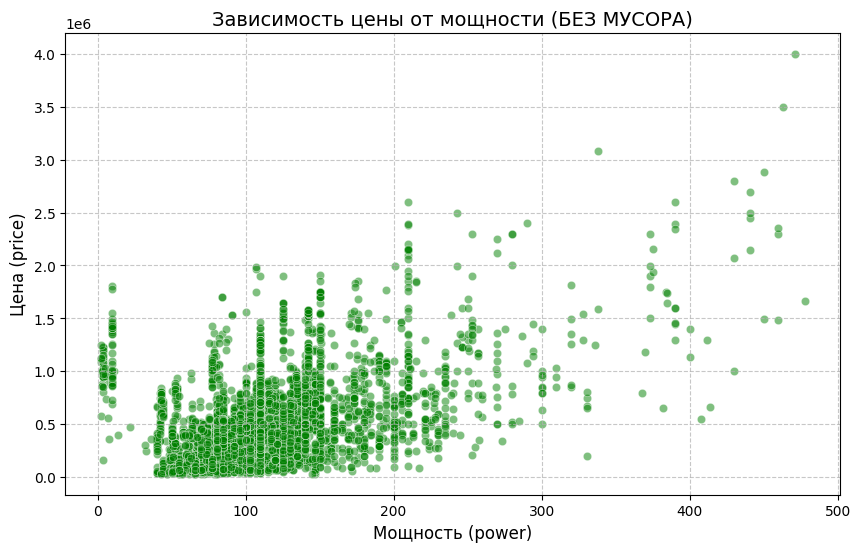

In [3]:
import numpy as np

# Создаем копию датафрейма для тестов
df_clean = df.copy()

# 1. Убираем "ракеты" (ограничиваем мощность адекватным лимитом, например, до 1000)
df_clean = df_clean[df_clean['power'] < 1000]

# 2. Превращаем заглушки "-1" обратно в пустоту (NaN)
# Метод .corr() в Pandas автоматически игнорирует NaN при расчетах!
df_clean['power'] = df_clean['power'].replace(-1, np.nan)

# 3. Считаем новую, ЧЕСТНУЮ корреляцию!
new_corr = df_clean['price'].corr(df_clean['power'])
print(f"🔥 Новая корреляция между ценой и мощностью: {new_corr:.2f}")

# 4. Строим здоровый график
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='power', y='price', alpha=0.5, color='green')
plt.title('Зависимость цены от мощности (БЕЗ МУСОРА)', fontsize=14)
plt.xlabel('Мощность (power)', fontsize=12)
plt.ylabel('Цена (price)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

🚀 Заводим мотор! Начинаем обучение модели...
0:	learn: 450015.9795706	test: 457995.7935986	best: 457995.7935986 (0)	total: 14.3ms	remaining: 14.3s
100:	learn: 207574.6760442	test: 224017.1666067	best: 224017.1666067 (100)	total: 725ms	remaining: 6.45s
200:	learn: 194788.8313750	test: 218961.8995947	best: 218961.8995947 (200)	total: 1.42s	remaining: 5.66s
300:	learn: 186165.0461081	test: 217659.9534117	best: 217659.9534117 (300)	total: 2.15s	remaining: 5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 217547.1202
bestIteration = 321

Shrink model to first 322 iterations.
------------------------------
🎉 НОВЫЙ R2 Score: 0.8033
💰 Средняя ошибка (MAE): 114,441 крон
------------------------------


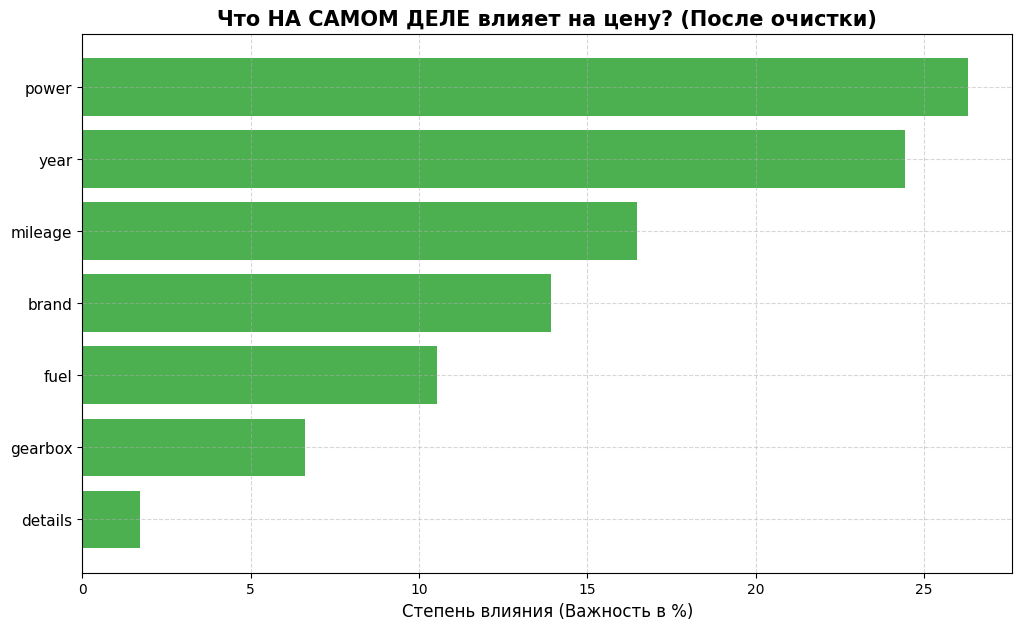

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем свежие данные
df = pd.read_csv('cars_ready.csv')

# --- ЗАМЕНИ БЛОК №2 В СВОЕМ КОДЕ НА ЭТОТ ---

# 2. 🔥 УМНАЯ ОЧИСТКА КОЛОНКИ POWER 🔥
# Убираем "ракеты" (мощность > 1000)
df = df[df['power'] < 1000]

# Заменяем мусор на честные пустоты (NaN)
df['power'] = df['power'].replace([-1, 0], np.nan)

# 🧠 УМНОЕ ЗАПОЛНЕНИЕ: Берем медиану мощности для КОНКРЕТНОЙ марки и модели!
# (Внимание: проверь, как у тебя называются колонки марки и модели. 
# Обычно это 'brand' и 'model' или 'mark' и 'model'. Замени, если у тебя иначе!)
# 🧠 УМНОЕ ЗАПОЛНЕНИЕ: Берем медиану мощности по МАРКЕ авто ('brand')
df['power'] = df.groupby('brand')['power'].transform(lambda x: x.fillna(x.median()))

# Если вдруг попались совсем уникальные машины, где вообще нет ни одной с указанной мощностью,
# добьем их общей медианой, чтобы не было ошибок
df['power'] = df['power'].fillna(df['power'].median())


# 3. 🛠️ ПОДГОТОВКА К ОБУЧЕНИЮ 🛠️
# Разделяем на фичи (X) и таргет (y)
X = df.drop('price', axis=1) 
y = df['price']

# 🔥 ИСПРАВЛЕНИЕ ОШИБКИ: Находим все текстовые колонки и лечим в них NaN
cat_columns = X.select_dtypes(include=['object']).columns
# Заменяем пустоты на текст 'Unknown'
X[cat_columns] = X[cat_columns].fillna('Unknown')
# Принудительно делаем их строками, чтобы CatBoost точно был счастлив
X[cat_columns] = X[cat_columns].astype(str)

# Теперь снова ищем индексы категориальных признаков
cat_features = np.where(X.dtypes == 'object')[0].tolist()

# Разбиваем на тренировочную и тестовую выборки (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 4. 🧠 ОБУЧЕНИЕ МОДЕЛИ 🧠
print("🚀 Заводим мотор! Начинаем обучение модели...")
model = CatBoostRegressor(
    iterations=1000, 
    learning_rate=0.1, 
    depth=8, 
    random_seed=42, 
    verbose=100 
)

# Учим!
model.fit(
    X_train, y_train, 
    cat_features=cat_features, 
    eval_set=(X_test, y_test), 
    early_stopping_rounds=50
)


# 5. 🎯 ОЦЕНКА РЕЗУЛЬТАТОВ 🎯
y_pred = model.predict(X_test)
new_r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("-" * 30)
print(f"🎉 НОВЫЙ R2 Score: {new_r2:.4f}")
print(f"💰 Средняя ошибка (MAE): {mae:,.0f} крон")
print("-" * 30)


# 6. 📊 НОВЫЙ ГРАФИК ВАЖНОСТИ ПРИЗНАКОВ 📊
feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(12, 7))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center', color='#4CAF50')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx], fontsize=11)
plt.title('Что НА САМОМ ДЕЛЕ влияет на цену? (После очистки)', fontsize=15, fontweight='bold')
plt.xlabel('Степень влияния (Важность в %)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

print("🧹 1. Загрузка и умная очистка данных...")
df = pd.read_csv('/Users/kuzetshy20/Documents/autoProject/cars_ready.csv')

df = df[df['power'] < 1000]
df['power'] = df['power'].replace([-1, 0], np.nan)
df['power'] = df.groupby('brand')['power'].transform(lambda x: x.fillna(x.median()))
df['power'] = df['power'].fillna(df['power'].median())

print(f"✅ Этап 1 готов! Размер данных: {df.shape}")

🧹 1. Загрузка и умная очистка данных...
✅ Этап 1 готов! Размер данных: (18823, 8)


In [3]:
print("🧠 2. Создание новых фичей (возраст, 4x4, кластеры)...")
X_cluster = df[['year', 'mileage', 'power']].copy().fillna(df[['year', 'mileage', 'power']].median())
X_scaled = StandardScaler().fit_transform(X_cluster)
df['segment'] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_scaled).astype(str)

df['car_age'] = 2026 - df['year']
df['details'] = df['details'].fillna("Unknown").astype(str)
details_lower = df['details'].str.lower()

df['is_4x4'] = details_lower.str.contains(r'4x4|awd|quattro|xdrive|4matic').astype(int)
df['is_automatic'] = details_lower.str.contains(r'automat|dsg|tiptronic|stronic').astype(int)
df['is_sport'] = details_lower.str.contains(r'rs|gti|m-packet|amg|sport|s-line').astype(int)
df['has_led'] = details_lower.str.contains(r'led|matrix|xenon').astype(int)

print("✅ Этап 2 готов! Фичи добавлены.")

🧠 2. Создание новых фичей (возраст, 4x4, кластеры)...
✅ Этап 2 готов! Фичи добавлены.


In [4]:
print("📉 3. Подготовка к обучению...")
# ВАЖНО: Удаляем тяжелую колонку details
X = df.drop(columns=['price', 'details']) 
y = df['price']
y_log = np.log1p(y) 

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

cat_features = ['brand', 'fuel', 'gearbox', 'segment'] 
for col in cat_features:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

print("✅ Этап 3 готов! Данные разбиты на X_train и X_test.")

📉 3. Подготовка к обучению...
✅ Этап 3 готов! Данные разбиты на X_train и X_test.


In [5]:
%%time
print(f"🚀 4. Заводим CatBoost (на {len(X_train)} машин)...")
model = CatBoostRegressor(
    iterations=1500,    
    learning_rate=0.08, 
    depth=7,
    loss_function='RMSE',
    verbose=100,        
    random_seed=42
)

model.fit(
    X_train, y_train_log, 
    cat_features=cat_features,
    eval_set=(X_test, y_test_log),
    early_stopping_rounds=50
)

print("\n✅ Модель успешно обучена!")
model.save_model("car_price_model_FINAL.cbm")
print("💾 Модель сохранена в файл car_price_model_FINAL.cbm")

🚀 4. Заводим CatBoost (на 15058 машин)...
0:	learn: 0.8274531	test: 0.8454489	best: 0.8454489 (0)	total: 63.4ms	remaining: 1m 35s
100:	learn: 0.2822030	test: 0.2942415	best: 0.2942415 (100)	total: 491ms	remaining: 6.8s
200:	learn: 0.2637943	test: 0.2827956	best: 0.2827956 (200)	total: 898ms	remaining: 5.8s
300:	learn: 0.2543074	test: 0.2785344	best: 0.2785344 (300)	total: 1.33s	remaining: 5.29s
400:	learn: 0.2471603	test: 0.2760134	best: 0.2760134 (400)	total: 1.72s	remaining: 4.72s
500:	learn: 0.2421481	test: 0.2751893	best: 0.2751893 (500)	total: 2.12s	remaining: 4.23s
600:	learn: 0.2376899	test: 0.2742983	best: 0.2742762 (592)	total: 2.51s	remaining: 3.76s
700:	learn: 0.2337452	test: 0.2739806	best: 0.2739465 (668)	total: 2.93s	remaining: 3.34s
800:	learn: 0.2306883	test: 0.2735907	best: 0.2735617 (784)	total: 3.35s	remaining: 2.93s
900:	learn: 0.2273829	test: 0.2731837	best: 0.2731455 (879)	total: 3.8s	remaining: 2.52s
1000:	learn: 0.2246221	test: 0.2729744	best: 0.2729744 (1000)	t

📊 5. Считаем метрики и рисуем графики...

🏆 ФИНАЛЬНЫЙ СУПЕР-РЕЗУЛЬТАТ:
📊 Точность (R2 Score): 0.8098
💰 Средняя ошибка (MAE): 106,062 CZK


/var/folders/nf/_plpz1p57pv31n9md8s7b1s40000gn/T/ipykernel_28948/3130567516.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importances", y="Feature Id", data=feat_imp, palette="magma", ax=axes[1])


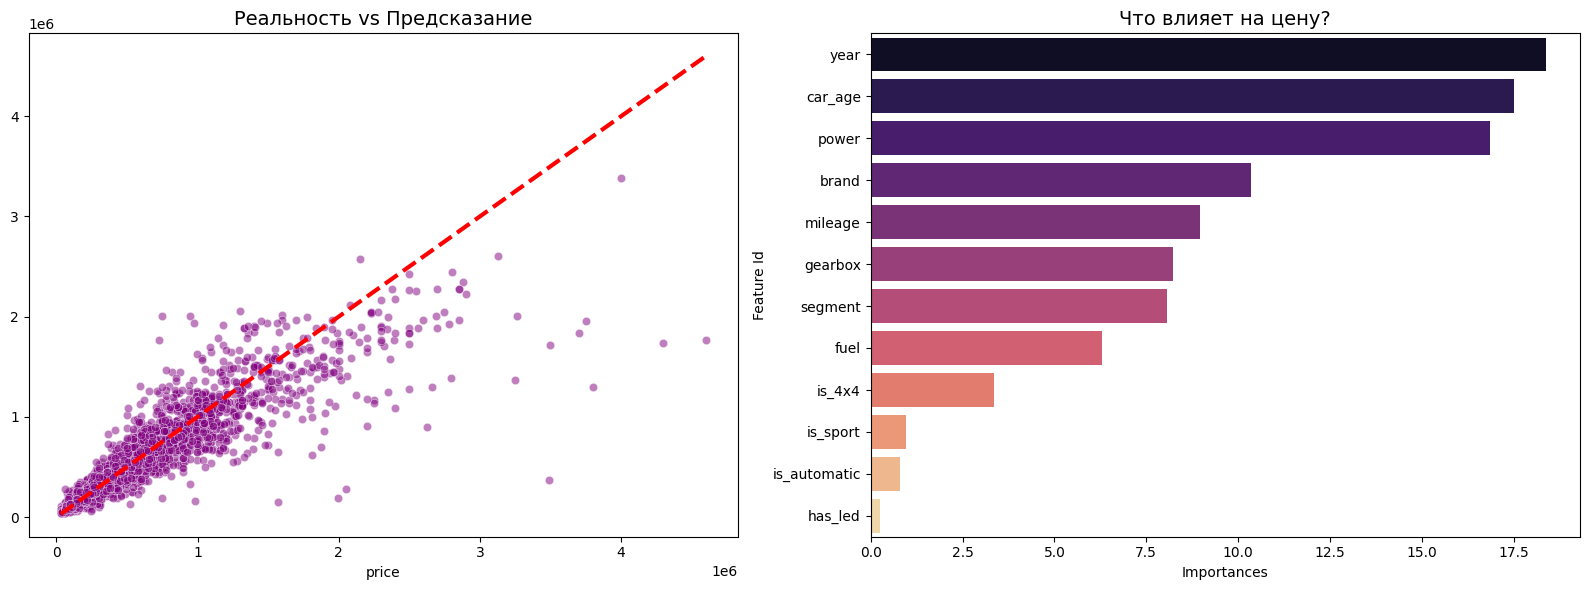

In [6]:
print("📊 5. Считаем метрики и рисуем графики...")
predictions_real = np.expm1(model.predict(X_test))
y_test_real = np.expm1(y_test_log)

r2 = r2_score(y_test_real, predictions_real)
mae = mean_absolute_error(y_test_real, predictions_real)

print("\n" + "="*45)
print(f"🏆 ФИНАЛЬНЫЙ СУПЕР-РЕЗУЛЬТАТ:")
print(f"📊 Точность (R2 Score): {r2:.4f}") 
print(f"💰 Средняя ошибка (MAE): {mae:,.0f} CZK")
print("="*45)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x=y_test_real, y=predictions_real, alpha=0.5, color='purple', ax=axes[0])
axes[0].plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=3)
axes[0].set_title('Реальность vs Предсказание', fontsize=14)

feat_imp = model.get_feature_importance(prettified=True).head(15)
sns.barplot(x="Importances", y="Feature Id", data=feat_imp, palette="magma", ax=axes[1])
axes[1].set_title('Что влияет на цену?', fontsize=14)

plt.tight_layout()
plt.show()

In [7]:
import os

filename = "car_price_model_FINAL.cbm"

if os.path.exists(filename):
    print(f"✅ ФАЙЛ НАЙДЕН! Он лежит здесь: {os.path.abspath(filename)}")
else:
    print("❌ Файла нет. Давай попробуем сохранить его принудительно еще раз.")
    # Если файла нет, эта строчка его создаст прямо сейчас
    model.save_model(filename)
    print("💾 Попытка повторного сохранения завершена. Проверяй колонку!")

✅ ФАЙЛ НАЙДЕН! Он лежит здесь: /Users/kuzetshy20/Desktop/car_price_model_FINAL.cbm
